#**Proyecto final - Formula 1**

**Integrantes:**

- Edwin Leal Guadalajara

- Kevin Javier Perez Meza

- María Fernanda Sánchez Rentería

- Fernanda Lizeth Zambrano Gudiño

La Formula 1 es la competición más popular de automovilismo. El dataset utilizado cuenta con la información de las carreras, conductores, pitstops, circuitos, entre otros, para el proyecto se utilizarán PitStops, Conductores y Posicionamiento.

**Materias:**


- Estadística


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import gamma as gamma
import scipy.integrate as integrate
import scipy

##**Limpieza de datos**

In [ ]:
#Base de datos a utilizar:

#almacena los datos en la variable df_ps (pit stops)
url_ps = 'https://raw.githubusercontent.com/IvTole/MachineLearning_InferenciaBayesiana_CUGDL/refs/heads/main/data/formula1/pit_stops.csv'

url_dr = 'https://raw.githubusercontent.com/IvTole/MachineLearning_InferenciaBayesiana_CUGDL/refs/heads/main/data/formula1/drivers.csv'

url_stan = 'https://raw.githubusercontent.com/IvTole/MachineLearning_InferenciaBayesiana_CUGDL/refs/heads/main/data/formula1/driver_standings.csv'

In [ ]:
df_feo_ps = pd.read_csv(url_ps)
df_feo_dr = pd.read_csv(url_dr)
df_feo_stan = pd.read_csv(url_stan)

#---Limpieza de datos---#

# se eliminan columnas innecesarias y redundantes

df_ps=(df_feo_ps
    .drop(columns=['time', 'duration']) #elimina columnas
    .loc[lambda df: df['stop']<7] # quita valores mayores a 7 en stop
    .groupby(['raceId', 'driverId']) #agrupa conductores y carreras
    .agg(
        stop=('stop', 'max'), #se queda con el maximo de paradas🥵
        milliseconds=('milliseconds', 'sum') #por cada parada se suman los ms
    )
    .assign(seconds=lambda df:df['milliseconds']/1000) #se transforma en seg
    .drop(columns=['milliseconds']) #Se quita la col de ms
    .reset_index()
    )

df_dr=(df_feo_dr
    .drop(columns=['url', 'number', 'code', 'surname', 'dob']) #elimina columnas
    )

df_stan=(df_feo_stan
    .drop(columns=['driverStandingsId', 'positionText', 'points', 'wins']) #Quitar columnas innecesatias
    .loc[lambda df:df['position']<11] #quitar posiciones mayores a 11
)
#crear dos clases, una de podio, ota dentro de puntos.
df_stan['clase_pos'] = pd.cut(
  df_stan['position'],
    bins=[0, 3, 10],
    labels=[1, 0], #podio = 1, puntos = 0
    include_lowest=True
)

'''
Crear un nuevo dataframe donde el nombre del conductor se identifique en
con el driverId y se agregue en una nueva columna correspondiente con su
Id de conductor
'''

df_ps_dr = df_ps.merge(df_dr, on='driverId', how='left') #Combina Pitstop y Drivers (PsDr)
df_psdrstan = df_ps_dr.merge(df_stan, on=['raceId', 'driverId'], how='left')
df_limpio = df_psdrstan.dropna().reset_index(drop=True) #Combina PsDr y standings


print(f'---PitStops, Drivers y Standings unidos---\n')
display(df_limpio.head())

#Aseguramos que no haya ningun valor nulo
null_counts = df_limpio.isnull().sum()
null_percent = (null_counts / len(df_limpio)) * 100

missing_data = pd.DataFrame({
    'Valores nulos': null_counts,
    '% del total': null_percent.round(2)
})
print('\n---Valores nulos---\n')
display(missing_data)

print(f'\n{df_limpio.shape}')

---PitStops, Drivers y Standings unidos---



,raceId,driverId,stop,seconds,driverRef,forename,nationality,position,clase_pos
0,841,1,2,46.426,hamilton,Lewis,British,2.0,1
1,841,4,3,72.165,alonso,Fernando,Spanish,4.0,0
2,841,13,3,72.437,massa,Felipe,Brazilian,7.0,0
3,841,16,2,49.849,sutil,Adrian,German,9.0,0
4,841,17,3,72.176,webber,Mark,Australian,5.0,0



---Valores nulos---



,Valores nulos,% del total
raceId,0,0.0
driverId,0,0.0
stop,0,0.0
seconds,0,0.0
driverRef,0,0.0
forename,0,0.0
nationality,0,0.0
position,0,0.0
clase_pos,0,0.0



(2702, 9)


##**Estadística descriptiva**

,count
stop,
2,1079
1,931
3,498
4,145
5,36
6,13


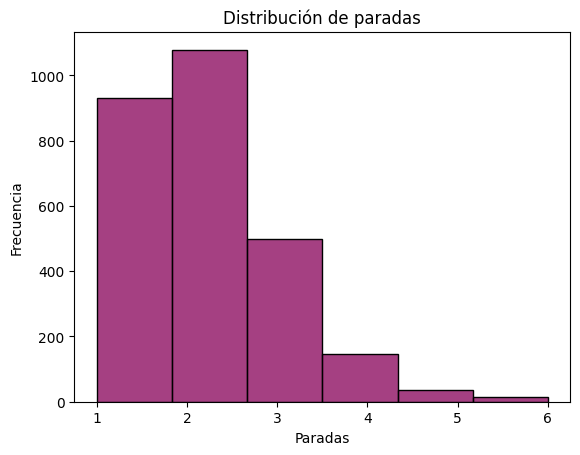

In [ ]:
df_p = df_limpio['stop'].value_counts().to_frame() #Hacer un dataframe con la cuenta final de cuantas veces se han parado los conductores
display(df_p)

sns.histplot(data =df_limpio['stop'], bins=6, color='#870058')
plt.title('Distribución de paradas en boxes')
plt.xlabel('Paradas')
plt.ylabel('Frecuencia')
plt.show()

nationality
Británico      548
Otro           419
Alemán         385
Español        302
Finlandés      298
Australiano    223
Mexicano       188
Holandés       178
Francés        161
Name: count, dtype: int64


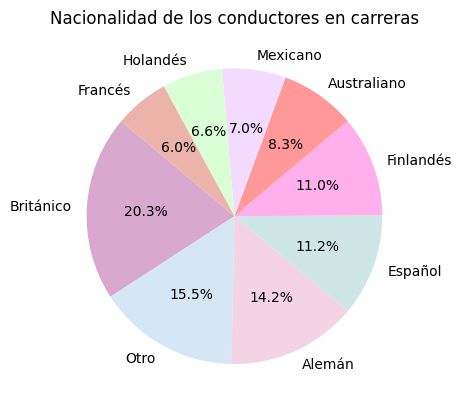

In [ ]:
#Hay nacionalidades las cuales cuentan con muy pocos conductores, es por ello que se agregan a un solo grupo: Otro
nationality = df_limpio['nationality'].replace({
    'British' : 'Británico',
    'German' : 'Alemán',
    'Spanish' : 'Español',
    'Finnish' : 'Finlandés',
    'Australian' : 'Australiano',
    'Mexican' : 'Mexicano',
    'Dutch' : 'Holandés',
    'French' : 'Francés',
    'Monegasque': 'Otro',
    'Brazilian' : 'Otro',
    'Russian': 'Otro',
    'Danish' : 'Otro',
    'Canadian' : 'Otro',
    'Thai': 'Otro',
    'Japanese': 'Otro',
    'Venezuelan': 'Otro',
    'Swiss' : 'Otro',
    'Belgian' : 'Otro',
    'Swedish' : 'Otro',
    'Italian' : 'Otro',
    'Chinese' : 'Otro'
})
nationality_counts = nationality.value_counts()
print(nationality_counts)

labels = nationality_counts.index
sizes = nationality_counts.values
colors = ['#d8a8ce', '#d5e6f5', '#f4d4e4', '#cee6e6', '#FFAFEB', '#ff9999', '#f3daff', '#daffd6', '#ebb3a9']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Nacionalidad de los conductores en carreras')
plt.show()

In [ ]:
#---Medidas de tendencia central---

df_stop = df_limpio['stop'] #Se generan nuevos dataframes con variables que nos interesan
df_seconds = df_limpio['seconds']

'''
Se seleccionaron las variables 'stop' y 'seconds' porque unas son variables categóricas y otras son
variablees numéricas irrelevantes, 'positions' se distribuye de manera uniforme entonces no daría un
resultado correcto, driverId y raceId solo son los identificadores, no son variables que aportan
información estadística.
'''

print(f'---Medidas de tendencia central---\n')
print(f'Media de paradas: {df_stop.mean():.2f}')
print(f'Media de segundos: {df_seconds.mean():.2f} segundos\n')

print(f'Mediana de paradas: {df_stop.median()}')
print('Los segundos son únicos por lo que no se puede calcular la mediana\n')

print(f'Moda de paradas: {df_stop.mode()[0]}')
print('Los segundos son únicos por lo que no se puede calcular la moda\n')

#---Medidas de dispersión---

print(f'---Medidas de dispersión---\n')

print(f'Varianza de las paradas: {df_stop.var():.2f}')
print(f'Varianza de los segundos: {df_seconds.var():.2f}\n')

print(f'Desviación estándar de las paradas: {df_stop.std():.2f}')
print(f'Desviación estándar de los segundos: {df_seconds.std():.2f}\n')

print(f'Rango de las paradas: {df_stop.max() - df_stop.min()}')
print(f'Rango de los segundos: {(df_seconds.max() - df_seconds.min()):.2f}')

---Medidas de tendencia central---

Media de paradas: 2.01
Media de segundos: 183.47 segundos

Mediana de paradas: 2.0
Los segundos son únicos por lo que no se puede calcular la mediana

Moda de paradas: 2
Los segundos son únicos por lo que no se puede calcular la moda

---Medidas de dispersión---

Varianza de las paradas: 0.94
Varianza de los segundos: 272835.30

Desviación estándar de las paradas: 0.97
Desviación estándar de los segundos: 522.34

Rango de las paradas: 5
Rango de los segundos: 3685.58


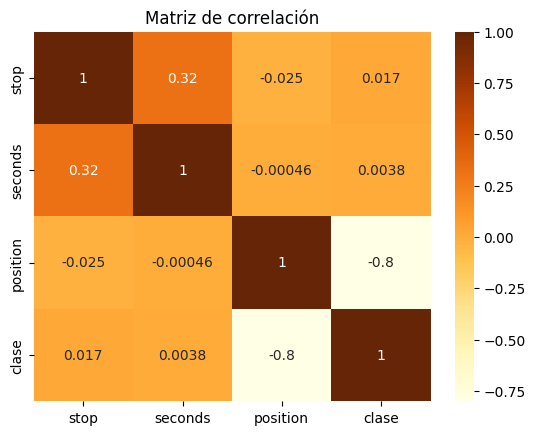

In [ ]:
#Matriz de correlacion

df_num = df_limpio[['stop', 'seconds', 'position', 'clase']]

sns.heatmap(df_num.corr(), cmap='YlOrBr', annot=True)
plt.title('Matriz de correlación')
plt.show()

##**Pruebas estadísticas**

###Prueba de normalidad de Shapiro-Wilk

Una prueba de normalidad de Shapiro-Wilk evalua si los datos siguen una distribución normal. Un p-valor alto indica que los datos se comportan aproximadamente normal y un p-valor bajo indica que no sigue una distribución normal (Malato, 2025)

Para esta prueba se utilizará el estadístico:

\begin{equation}
W = \frac{(\sum_{i=1}^n a_i x_{(i)})^2}{\sum_{i=1}^n (x_i -\bar{x})^2} = \frac{B^2}{S^2}
\end{equation}

$\bar{x}$: media muestral

$S^2$: suma de los cuadrados

$a_i: \frac{m^T V^{-1}}{(m^T V^{-1} V^{-1}m)^{1/2}}$

Hipótesis:

$H_0$: Los datos se ajustan a una distribución normal.

$H_1$: Los datos no se ajustan a una dsitribución normal.

In [ ]:
def tabla(name):
    #---Sacar la tabla de primeras y últimas carreras del conductor
    df_name = df_limpio[df_limpio['driverRef']==name]
    df_tail = df_name.tail(10).reset_index(drop=True)
    df_head = df_name.head(10).reset_index(drop=True)
    elim_cols = ['driverId', 'stop', 'seconds', 'nationality', 'raceId', 'forename', 'clase']
    df_tail = (df_tail.drop(columns=elim_cols))
    df_head = (df_head.drop(columns=elim_cols))
    df_name = pd.concat([df_head, df_tail], axis=1)
    print(f'---Comparación de segundos en pitstops en las primeras y ultimas carreras de {name.capitalize()}---\n')
    shapiro_wilk(df_name, df_head, df_tail)

import scipy.stats as st

def shapiro_wilk(df_name, df_head, df_tail):
    if len(df_name) < 10:
        print('No hay suficientes datos para realizar la prueba')
        return None
    array_tail = df_tail['position'].to_numpy() #Transformarlos en arreglos
    array_head = df_head['position'].to_numpy()
    array = array_tail - array_head #Restarlos para prueba pareada
    array_sorted = np.sort(array) #Ordenarlos de menor a mayor
    media_muestral = array_sorted.mean() #Sacar la media

    n = len(array_sorted) #dimension
    b = 0.0

    '''
    los coeficientes de shapiro-wilk se obtienen de tomar una curva normal estandarizada N(0, 1), se calculan
    estadísticos esperados de una curva normal para construir un vector, se sacan las covarianzas de los valores
    ordenados y se construyen los coeficientes ajustando los pesos, basicamente se comparan los datos ordenados
    por como se verian si fueran normales
    '''
    coeficientes = {
        10: [0.5739, 0.3291, 0.2141, 0.1224, 0.0399]
    }
    m = n // 2

    '''
      Se creo un loop porque en esta prueba se deben sacar las diferencias entre el primer numero de
      la tabla con el ultimo y asi sucesivamente. A los resultados de cada pareja se le debe multiplicar
      un coeficiente, como se muestra en orden:  coeficientes = {
          10: [0.5739, 0.3291, 0.2141, 0.1224, 0.0399]
      }
      Finalmente los resultados se suman para obtener el valor de B.
    '''
    for i in range(m):
        resta = array_sorted[n - 1 - i] - array_sorted[i]
        a_i = coeficientes[n][i]
        b += a_i * resta
    print(f"Valor de B: {b:.4f}")

    # denominador
    denominador = np.sum((array_sorted - media_muestral) ** 2)
    print(f'Valor de S^2: {denominador:.4f}')

    W = (b ** 2) / denominador

    print(f"\n-- Resultado de Shapiro-Wilk --")
    print('B^2/S^2 = W')
    print(f"W = {W:.4f}")

      # valor crítico aproximado
    alpha = 0.05

    if W > alpha:
        print('Es aproximadamente normal')
        st.probplot(array,
               dist='norm',
               plot=plt)
        plt.show()
    else:
        print('No es normal')

    return W

---Comparación de segundos en pitstops en las primeras y ultimas carreras de Raikkonen---

Valor de B: 4.4074
Valor de S^2: 20.5000

-- Resultado de Shapiro-Wilk --
B^2/S^2 = W
W = 0.9476
Es aproximadamente normal


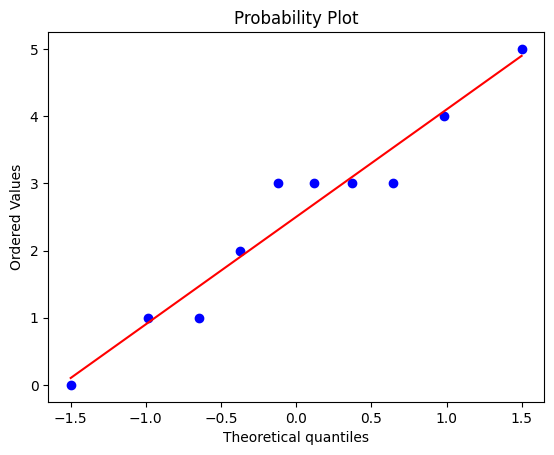

In [ ]:
tabla('raikkonen')

###Observaciones pareadas

La prueba t para observaciones pareadas es un método estadístico que determina si la diferencia de medias entre dos conjuntos de observaciones dependientes es cero (Statistics Solutions, 2026). Cada 'objeto' del cuál se le hace una medición tiene un par de datos de observaciones.

- Los datos no son variables independientes ni varibles aleatorias.

- Los datos deben seguir aproximadamente una distribución normal

In [ ]:
def tdist(t, nu):
  return scipy.special.gamma((nu+1.0)*0.5)/(scipy.special.gamma(nu*0.5)*np.sqrt(np.pi*nu))*(1.0+t**2/nu)**(-(nu+1.0)*0.5)

def observaciones_pareadas(name):
    # Volver a generar los mismos datos (igual que en tabla)
    df_name = df_limpio[df_limpio['driverRef']==name]
    df_tail = df_name.tail(10).reset_index(drop=True)
    df_head = df_name.head(10).reset_index(drop=True)
    elim_cols = ['driverId', 'stop', 'seconds', 'nationality', 'raceId', 'forename', 'clase']
    df_tail = (df_tail.drop(columns=elim_cols))
    df_head = (df_head.drop(columns=elim_cols))
    df_name = pd.concat([df_head, df_tail], axis=1)

    W = shapiro_wilk(df_name, df_head, df_tail) #Obtenemos W

    alpha = 0.05

    if W <= alpha:
        print('No se puede hacer la prueba pareada')
        return None

    print("\n--- Prueba de observaciones pareadas ---\n")
    display(df_name)

    # Diferencias
    array_tail = df_tail['position'].to_numpy()
    array_head = df_head['position'].to_numpy()
    dif = array_tail - array_head

    media_diferencia = dif.mean()

    print(f'Media de la diferencia: {media_diferencia:.4f}\n')
    print(f'la desviación estándar de las diferencias es: {np.sqrt(np.var(dif, ddof=1)):.3f}\n')

    n = len(dif)
    nu = n - 1

    z_arr = np.linspace(-10, 10, 1000)
    ss = 0

    for zval in z_arr:
        prob = integrate.quad(tdist, -np.inf, zval, args=(nu))
        if prob[0] >= 0.975:
            punto_crit = z_arr[ss-1]
            print(f'Punto critico: {punto_crit:.2f}')
            break
        ss += 1

    result1 = media_diferencia - punto_crit * np.sqrt(np.var(dif, ddof=1)/n)
    result2 = media_diferencia + punto_crit * np.sqrt(np.var(dif, ddof=1)/n)

    print(f'\n{result1} < mu < {result2}')

Valor de B: 4.4074
Valor de S^2: 20.5000

-- Resultado de Shapiro-Wilk --
B^2/S^2 = W
W = 0.9476
Es aproximadamente normal


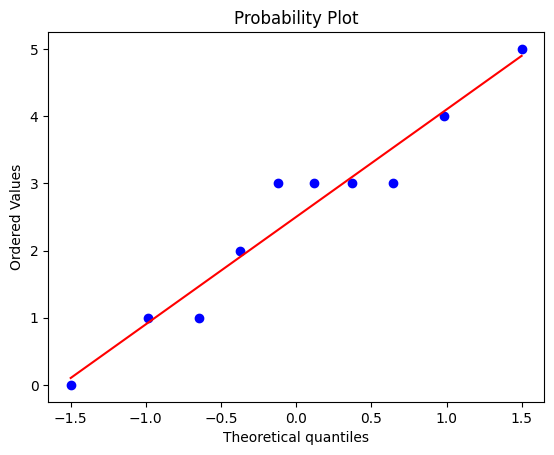


--- Prueba de observaciones pareadas ---



,driverRef,position,driverRef,position
0,raikkonen,7.0,raikkonen,7.0
1,raikkonen,7.0,raikkonen,8.0
2,raikkonen,8.0,raikkonen,9.0
3,raikkonen,7.0,raikkonen,10.0
4,raikkonen,4.0,raikkonen,8.0
5,raikkonen,6.0,raikkonen,9.0
6,raikkonen,6.0,raikkonen,8.0
7,raikkonen,6.0,raikkonen,9.0
8,raikkonen,5.0,raikkonen,8.0
9,raikkonen,4.0,raikkonen,9.0


Media de la diferencia: 2.5000

la desviación estándar de las diferencias es: 1.509

Punto critico: 2.25

1.425088508763037 < mu < 3.5749114912369633


In [ ]:
observaciones_pareadas('raikkonen')

*Resultados*

intervalo de confianza:

\begin{equation}
\bar{d} - t_{a/2} (n-1) \frac{S_d}{\sqrt{n}} < \mu_d < \bar{d} + t_{a/2} (n-1) \frac{S_d}{\sqrt{n}}
\end{equation}

Media de la diferencia: $\bar{d} = 2.5$

Valor crítico de t: $t_{0.05/2} = 2.25, \nu = n-1 = 9$

Desviación estándar muestral de la diferencia: $S_d = 1.509$

Raíz del tamaño de la muestra: $\sqrt{n} = \sqrt{10}$

\begin{equation}
2.5 - 2.25 \frac{1.509}{\sqrt{10}} < \mu_d < 2.5 + 2.25 \frac{1.509}{\sqrt{10}}
\end{equation}

\begin{equation}
1.42 < \mu_d < 3.57
\end{equation}

*Conclusiones:*

Con un alpha de 0.05, se dice que se tiene un 95% de confianza de que Raikkonen terminó en promedio 1.42 a 3.57 posiciones atrás en las últimas carreras registradass en comparación con sus primeras carreras registradas.

###Prueba de independencia $\chi^2$

Esta prueba confirma si es plausible que dos variables (en este caso, variables categóricas) están o no relacionadas.

Cuenta con las hipótesis:

$H_O:$ La variable 1 y la variable 2 no están relacionadas.

$H_1:$ La variable 1 y la variable 2 están relacionadas.

In [20]:
#¿los pitstops se relacionan con podio?

#Crear una clase para pitstops

df_limpio['clase_stops'] = pd.cut(
  df_limpio['stop'],
    bins=[1, 3, 6],
    labels=[1, 0], #1 al 3 = 1, 4 al 6 = 0
    include_lowest=True
)

#Se crea tabla de contingencia con las clases creadas
df_chi = df_limpio[['clase_pos', 'clase_stops']].groupby(['clase_pos', 'clase_stops'], observed=True).size().unstack(fill_value=0)
df_chi['total'] = df_chi.sum(axis=1)
df_chi.loc['total'] = df_chi.sum() #Se añaden las sumas de cada fila, columna y el total final
display(df_chi)

A = 2508 #sacado de las sumas de la tabla de contigencia
B = 194
C = 832
D = 1870

multiplicacion = np.array([A*C, A*D, B*C, B*D])
multiplicacion = np.array(multiplicacion/2702)

print(f'\n{multiplicacion}\n')

#Correccion de Yates

a = (((abs(df_chi[1][1]-multiplicacion[0]))-0.5)**2)/multiplicacion[0]
b = (((abs(df_chi[1][0]-multiplicacion[1]))-0.5)**2)/multiplicacion[1]
c = (((abs(df_chi[0][1]-multiplicacion[2]))-0.5)**2)/multiplicacion[2]
d = (((abs(df_chi[0][0]-multiplicacion[3]))-0.5)**2)/multiplicacion[3]

prueba_chi = a+b+c+d

print(f'\nChi cuadrada: {prueba_chi}')

clase_stops,1,0,total
clase_pos,,,
1,764,68,832
0,1744,126,1870
total,2508,194,2702



[ 772.26350851 1735.73649149   59.73649149  134.26350851]


Chi cuadrada: 1.5706445300831537


In [ ]:
def chi2(x, nu):
  num = (x**(nu*0.5-1))*np.exp(-x*0.5)
  den = 2.0**(nu*0.5)*gamma(nu*0.5)
  return num/den

z_arr=np.linspace(0.001, 10, 1000)
nu= 1 #(r-1)(c-1) = (2-1)(2-1) = 1

ss =0
for zval in z_arr:
  prob = integrate.quad(chi2, 0.00001, zval, args=(nu))
  right_tail=1-prob[0]
  if right_tail<= 0.05:
    print(z_arr[ss-1])
    break
  ss += 1

3.9245315315315317


/tmp/ipykernel_1527/616314081.py:2: RuntimeWarning: divide by zero encountered in power
  num = (x**(nu*0.5-1))*np.exp(-x*0.5)


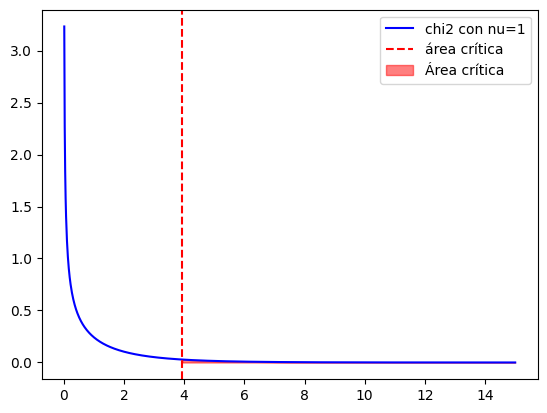

In [ ]:
from matplotlib import lines
nu = 1
x_arr = np.linspace(0, 15,1000)
plt.plot(x_arr, chi2(x_arr, nu), linestyle='-', marker='', color='b', label='chi2 con nu=1')
plt.axvline(x=3.9245, color='red', linestyle='--', label='área crítica')
x_critico = 3.9245

# área crítica
plt.fill_between(
    x_arr,
    chi2(x_arr, nu),
    where=(x_arr >= x_critico),
    color='red',
    alpha=0.5,
    label='Área crítica')
plt.legend()
plt.show()

Los datos obtenidos a través de la prueba de independencia $\chi^2$ nos dan lo siguiente:

- Corrección de Yates

$\chi^2 = \sum_i \frac{(|o_i - e_i|-0.5)^2}{e_i}$ que finalmente se obtiene $1.5706$

\begin{equation}
\int_{\chi^2_{0.05, \nu = 1}}^{\infty} f(x) \,dx = 0.05
\end{equation}

El valor del punto crítico da como resultado $\approx 3.9224$

Entonces, en este caso: $\chi^2  < \chi_{crit}^2$ lo que significa que no hay evidencia suficiente para rechazar la hipótesis nula. Los datos no son dependientes




##ANOVA de un factor

Método estadístico que determina si tres o más medias son iguales o no.

Las hipótesis son las siguientes:

$H_0: \mu_1 = \mu_2 = ... = \mu_k$

$H_1$: al menos una de las medias de es diferente sobre las demás.

In [17]:
def SSA(n, k, yi_mean, y_mean):
    summ = 0.0
    for i in range(k):
        summ += (yi_mean[i] - y_mean)**2
    return n * summ

def SSE(n, k, yij, yi_mean):
    summ = 0.0
    for i in range(k):
        for j in range(n):
            summ += (yij[j, i] - yi_mean[i])**2
    return summ

In [18]:
# n = observaciones por grupo
n = 4

# k = número de grupos
k = 3

#pits 1
yij1 = np.array([2, 3, 4, 5])

#pits 2
yij2 = np.array([5, 6, 7, 8])

#pits 3
yij3 = np.array([8, 9, 7, 10])

#medias
yi_mean1 = np.array(yij1.mean())
yi_mean2 = np.array(yij2.mean())
yi_mean3 = np.array(yij3.mean())

yi_mean = np.asarray([
    yi_mean1,
    yi_mean2,
    yi_mean3
])

y_mean = yi_mean.mean()

#SSA
SSA_val = SSA(n, k, yi_mean, y_mean)

#S1
S1 = SSA_val / (k - 1.0)

print(f'SSA = {SSA_val}')
print(f'S1 = {S1}')

yij = np.zeros((n, k), dtype=np.float64)

# Grupo 1
yij[0,0]= 2
yij[1,0]= 3
yij[2,0]= 4
yij[3,0]= 5

# Grupo 2
yij[0,1]= 5
yij[1,1]= 6
yij[2,1]= 7
yij[3,1]= 8

# Grupo 3
yij[0,2]= 8
yij[1,2]= 9
yij[2,2]= 7
yij[3,2]= 10

#SSE
SSE_val = SSE(n, k, yij, yi_mean)

#S2
S2 = SSE_val / (k * (n - 1))
print(f'SSE = {SSE_val}')
print(f'S2 = {S2}')

#Prueba F
F_val = S1 / S2

print(f'F = {F_val}')

SSA = 50.666666666666664
S1 = 25.333333333333332
SSE = 15.0
S2 = 1.6666666666666667
F = 15.2


*Conclusiones*

El análisis ANOVA permitió comparar las posiciones finales de los pilotos agrupados según el número de pit stops realizados durante las carreras. Los resultados obtenidos mostraron que la variabilidad entre grupos fue considerablemente mayor que la variabilidad dentro de los grupos, reflejándose en un valor elevado del estadístico F. Esto indica que existen diferencias significativas entre los grupos analizados, es decir que las medias de cada grupo son distintas.

##bibliografia


Malato, G. (2025, 1 agosto). An Introduction to the Shapiro-Wilk Test for Normality. Built In. https://builtin.com/data-science/shapiro-wilk-test

Test de normalidad de Shapiro - Wilk (a mano). (2021, 1 agosto). [Vídeo]. YouTube. Recuperado 1 de mayo de 2026, de https://youtu.be/R0OIikqfDdE?si=AJiIynzpP1eg2Wbg


Statistics Solutions. (2026, 16 abril). Paired Sample T-Test - Statistics solutions. https://www.statisticssolutions.com/free-resources/directory-of-statistical-analyses/paired-sample-t-test/#:~:text=En%20una%20prueba%20t%20para%20muestras%20pareadas%2C,lo%20que%20resulta%20en%20pares%20de%20observaciones.


Walpole, R., Myers, R., Myers, S., & Keying, Y. (2012). Probabilidad y estadística para ingeniería y ciencias (9.a ed.) [Pearson Educación de México, S.A. de C.V.]. Mario Contreras. https://bibliotecavirtualaserena.wordpress.com/wp-content/uploads/2017/05/libro_probabilidad-y-estadistica-para-ingenerc3ada-y-ciencias-ronald-e-walpole-mayers.pdf